In [1]:
!pip install piexif -q
import os, cv2, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from datetime import datetime
from collections import Counter
import piexif
warnings.filterwarnings('ignore')
print("✅ All libraries loaded!")


✅ All libraries loaded!


In [2]:
from google.colab import files
import zipfile, os

# Upload your kaggle.json API file
files.upload()  # upload kaggle.json

# Setup Kaggle
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download the dataset directly
!kaggle datasets download -d mahmoudreda55/satellite-image-classification
!unzip -q satellite-image-classification.zip -d /content/data

# Check
for cls in ['cloudy', 'desert', 'green_area', 'water']:
    path = f"/content/data/{cls}"
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"  ✅ {cls}: {count} images")

Saving kaggle3.json to kaggle3.json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification
License(s): copyright-authors
100% 21.8M/21.8M [00:00<00:00, 133MB/s]



In [11]:
DATASET_PATH = "/content/satellite/data"
OUTPUT_PATH  = "./pii_output"
CLASSES      = ["cloudy", "desert", "green_area", "water"]
SAMPLE_LIMIT = 10

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(f"{OUTPUT_PATH}/clean_images", exist_ok=True)
os.makedirs(f"{OUTPUT_PATH}/reports", exist_ok=True)
print("✅ Config set. Output folder ready.")


✅ Config set. Output folder ready.


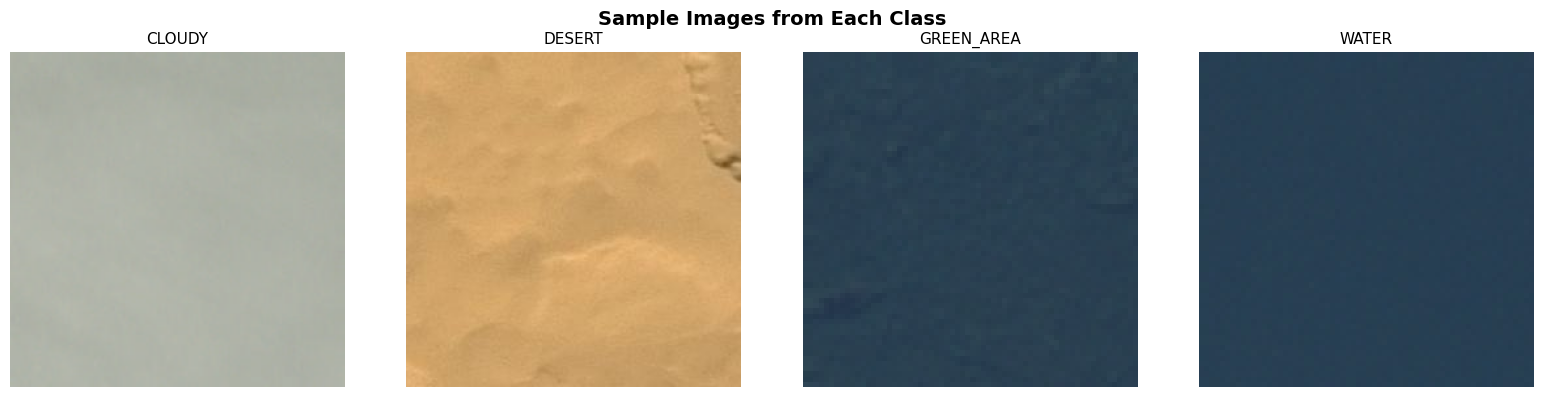

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Sample Images from Each Class", fontsize=14, fontweight='bold')

for i, cls in enumerate(CLASSES):
    cls_path = Path(DATASET_PATH) / cls
    images = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    if images:
        img = Image.open(images[0])
        axes[i].imshow(img)
        axes[i].set_title(cls.upper(), fontsize=11)
        axes[i].axis('off')

plt.tight_layout()
plt.show()


In [13]:
def extract_exif(image_path):
    """Extract PII from image EXIF metadata."""
    pii_found = {}
    try:
        img = Image.open(image_path)
        exif_bytes = img.info.get("exif", b"")
        if not exif_bytes:
            return {"status": "No EXIF data found"}

        exif_data = piexif.load(exif_bytes)

        # GPS — most critical PII
        gps = exif_data.get("GPS", {})
        if gps and piexif.GPSIFD.GPSLatitude in gps:
            def to_deg(val):
                d, m, s = val
                return d[0]/d[1] + m[0]/m[1]/60 + s[0]/s[1]/3600
            lat = to_deg(gps[piexif.GPSIFD.GPSLatitude])
            lon = to_deg(gps[piexif.GPSIFD.GPSLongitude])
            lat_ref = gps.get(piexif.GPSIFD.GPSLatitudeRef, b'N').decode()
            lon_ref = gps.get(piexif.GPSIFD.GPSLongitudeRef, b'E').decode()
            if lat_ref == 'S': lat = -lat
            if lon_ref == 'W': lon = -lon
            pii_found["GPS_Latitude"]  = round(lat, 6)
            pii_found["GPS_Longitude"] = round(lon, 6)
            pii_found["GPS_Risk"]      = "🔴 HIGH — Exact location exposed"

        zeroth = exif_data.get("0th", {})
        if piexif.ImageIFD.Make in zeroth:
            pii_found["Device_Make"]  = zeroth[piexif.ImageIFD.Make].decode(errors='ignore')
            pii_found["Device_Risk"]  = "🟡 MEDIUM — Device fingerprint"
        if piexif.ImageIFD.Model in zeroth:
            pii_found["Device_Model"] = zeroth[piexif.ImageIFD.Model].decode(errors='ignore')
        if piexif.ImageIFD.DateTime in zeroth:
            pii_found["DateTime"]     = zeroth[piexif.ImageIFD.DateTime].decode(errors='ignore')
            pii_found["Time_Risk"]    = "🟢 LOW — Timestamp"
        if piexif.ImageIFD.Artist in zeroth:
            pii_found["Artist"]       = zeroth[piexif.ImageIFD.Artist].decode(errors='ignore')
            pii_found["Artist_Risk"]  = "🔴 HIGH — Direct personal identifier"

    except Exception as e:
        pii_found["status"] = f"No EXIF / unreadable: {e}"
    return pii_found

# Test on one image from each class
print("EXIF PII SCAN RESULTS")
print("="*55)
for cls in CLASSES:
    cls_path = Path(DATASET_PATH) / cls
    images = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    if images:
        result = extract_exif(str(images[0]))
        print(f"\n[{cls.upper()}] → {images[0].name}")
        if len(result) == 1 and "status" in result:
            print(f"  ✅ {result['status']}")
        else:
            for k, v in result.items():
                print(f"  ⚠️  {k}: {v}")


EXIF PII SCAN RESULTS

[CLOUDY] → train_12365.jpg
  ✅ No EXIF data found

[DESERT] → desert(516).jpg
  ✅ No EXIF data found

[GREEN_AREA] → Forest_2196.jpg
  ✅ No EXIF data found

[WATER] → SeaLake_1590.jpg
  ✅ No EXIF data found


In [14]:
def scrub_exif(image_path, output_path):
    """Remove ALL EXIF metadata from image — mitigates metadata PII."""
    try:
        img = Image.open(image_path)
        # Re-create image from raw pixel data (no metadata carried over)
        clean = Image.new(img.mode, img.size)
        clean.putdata(list(img.getdata()))
        clean.save(output_path)
        return True
    except Exception as e:
        return False

# Demo: scrub one image and verify
sample_cls = CLASSES[0]
sample_img = list((Path(DATASET_PATH) / sample_cls).glob("*.jpg"))[0]
clean_path = f"{OUTPUT_PATH}/clean_images/demo_clean.jpg"

scrub_exif(str(sample_img), clean_path)

# Compare before and after
before = extract_exif(str(sample_img))
after  = extract_exif(clean_path)

print("BEFORE SCRUBBING:")
print(before if before else "  No EXIF")
print("\nAFTER SCRUBBING:")
print(after if after else "  ✅ All EXIF removed — image is clean")


BEFORE SCRUBBING:
{'status': 'No EXIF data found'}

AFTER SCRUBBING:
{'status': 'No EXIF data found'}


In [15]:
def detect_visual_pii(image_path):
    """Detect PII within image content using OpenCV."""
    detections = []
    img_cv = cv2.imread(image_path)
    if img_cv is None:
        return detections, None

    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

    # 1. Face detection
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(20, 20))
    for (x, y, w, h) in faces:
        detections.append({"type": "FACE", "risk": "HIGH",
                           "bbox": (x, y, w, h),
                           "desc": "Biometric PII — face detected"})
        # Blur the face immediately
        img_cv[y:y+h, x:x+w] = cv2.GaussianBlur(img_cv[y:y+h, x:x+w], (99, 99), 30)

    # 2. Text region detection (MSER)
    mser = cv2.MSER_create()
    regions, _ = mser.detectRegions(gray)
    if len(regions) > 50:
        detections.append({"type": "TEXT_REGION", "risk": "MEDIUM",
                           "bbox": None,
                           "desc": f"Text-like regions ({len(regions)}) — may contain coordinates/IDs"})

    # 3. License plate-like rectangles
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    plate_count = 0
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect = w / float(h) if h > 0 else 0
        if 2.5 < aspect < 5.5 and 800 < w*h < 15000:
            plate_count += 1
    if plate_count > 0:
        detections.append({"type": "PLATE_CANDIDATE", "risk": "MEDIUM",
                           "bbox": None,
                           "desc": f"{plate_count} plate-like region(s) detected"})

    return detections, img_cv

# Test on a sample image
sample = list((Path(DATASET_PATH) / CLASSES[0]).glob("*.jpg"))[0]
dets, _ = detect_visual_pii(str(sample))
print(f"Visual PII scan on: {sample.name}")
if dets:
    for d in dets:
        print(f"  ⚠️  [{d['risk']}] {d['type']} — {d['desc']}")
else:
    print("  ✅ No visual PII detected in this image")


Visual PII scan on: train_12365.jpg
  ✅ No visual PII detected in this image


In [16]:
audit_records = []
total = pii_count = exif_count = visual_count = 0

for cls in CLASSES:
    cls_path = Path(DATASET_PATH) / cls
    images = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    if SAMPLE_LIMIT:
        images = images[:SAMPLE_LIMIT]

    print(f"\n[{cls.upper()}] Scanning {len(images)} images...")

    for img_path in images:
        total += 1
        record = {"filename": img_path.name, "class": cls,
                  "pii_detected": False, "risk_level": "NONE",
                  "exif_keys": [], "visual_types": [], "action": ""}

        # EXIF
        exif = extract_exif(str(img_path))
        has_exif = any(k in exif for k in ["GPS_Latitude", "Artist", "Device_Make"])
        record["exif_keys"] = list(exif.keys())

        # Visual
        dets, img_cv = detect_visual_pii(str(img_path))
        has_visual = len(dets) > 0
        record["visual_types"] = [d["type"] for d in dets]

        # Risk
        if has_exif and "GPS_Latitude" in exif:
            record["risk_level"] = "HIGH"
        elif has_exif or any(d["risk"] == "HIGH" for d in dets):
            record["risk_level"] = "MEDIUM"
        elif has_visual:
            record["risk_level"] = "LOW"

        if has_exif or has_visual:
            record["pii_detected"] = True
            pii_count += 1
            if has_exif:   exif_count   += 1
            if has_visual: visual_count += 1

        # Mitigate
        clean_path = f"{OUTPUT_PATH}/clean_images/{cls}_{img_path.name}"
        scrub_exif(str(img_path), clean_path)
        if img_cv is not None and dets:
            for d in dets:
                if d["bbox"]:
                    x, y, w, h = d["bbox"]
                    img_cv[y:y+h, x:x+w] = cv2.GaussianBlur(img_cv[y:y+h, x:x+w], (51,51), 20)
            cv2.imwrite(clean_path, img_cv)
        record["action"] = "EXIF scrubbed" + (f" + {len(dets)} region(s) blurred" if dets else "")

        audit_records.append(record)
        tag = "⚠️ PII" if record["pii_detected"] else "✅ OK"
        print(f"  {tag}  {img_path.name:35s} Risk: {record['risk_level']}")

print(f"\n{'='*55}")
print(f"  Total Scanned  : {total}")
print(f"  PII Found      : {pii_count}  ({pii_count/max(total,1)*100:.1f}%)")
print(f"  EXIF PII       : {exif_count}")
print(f"  Visual PII     : {visual_count}")
print(f"  All Cleaned    : {total}")
print(f"{'='*55}")



[CLOUDY] Scanning 10 images...
  ✅ OK  train_12365.jpg                     Risk: NONE
  ✅ OK  train_15469.jpg                     Risk: NONE
  ✅ OK  train_19500.jpg                     Risk: NONE
  ✅ OK  train_18626.jpg                     Risk: NONE
  ✅ OK  train_28215.jpg                     Risk: NONE
  ✅ OK  train_29680.jpg                     Risk: NONE
  ✅ OK  train_40475.jpg                     Risk: NONE
  ✅ OK  train_36545.jpg                     Risk: NONE
  ✅ OK  train_35846.jpg                     Risk: NONE
  ✅ OK  train_31296.jpg                     Risk: NONE

[DESERT] Scanning 10 images...
  ✅ OK  desert(516).jpg                     Risk: NONE
  ✅ OK  desert(581).jpg                     Risk: NONE
  ✅ OK  desert(484).jpg                     Risk: NONE
  ✅ OK  desert(102).jpg                     Risk: NONE
  ✅ OK  desert(1019).jpg                    Risk: NONE
  ✅ OK  desert(249).jpg                     Risk: NONE
  ✅ OK  desert(1081).jpg                    Risk: NONE
 

In [17]:
df = pd.DataFrame(audit_records)
df['exif_keys']    = df['exif_keys'].apply(lambda x: ', '.join(x))
df['visual_types'] = df['visual_types'].apply(lambda x: ', '.join(x) if x else 'None')

csv_path = f"{OUTPUT_PATH}/reports/pii_summary.csv"
df.to_csv(csv_path, index=False)
print(f"CSV saved: {csv_path}")
print(df[['filename','class','pii_detected','risk_level','action']].to_string(index=False))


CSV saved: ./pii_output/reports/pii_summary.csv
        filename      class  pii_detected risk_level        action
 train_12365.jpg     cloudy         False       NONE EXIF scrubbed
 train_15469.jpg     cloudy         False       NONE EXIF scrubbed
 train_19500.jpg     cloudy         False       NONE EXIF scrubbed
 train_18626.jpg     cloudy         False       NONE EXIF scrubbed
 train_28215.jpg     cloudy         False       NONE EXIF scrubbed
 train_29680.jpg     cloudy         False       NONE EXIF scrubbed
 train_40475.jpg     cloudy         False       NONE EXIF scrubbed
 train_36545.jpg     cloudy         False       NONE EXIF scrubbed
 train_35846.jpg     cloudy         False       NONE EXIF scrubbed
 train_31296.jpg     cloudy         False       NONE EXIF scrubbed
 desert(516).jpg     desert         False       NONE EXIF scrubbed
 desert(581).jpg     desert         False       NONE EXIF scrubbed
 desert(484).jpg     desert         False       NONE EXIF scrubbed
 desert(102).j

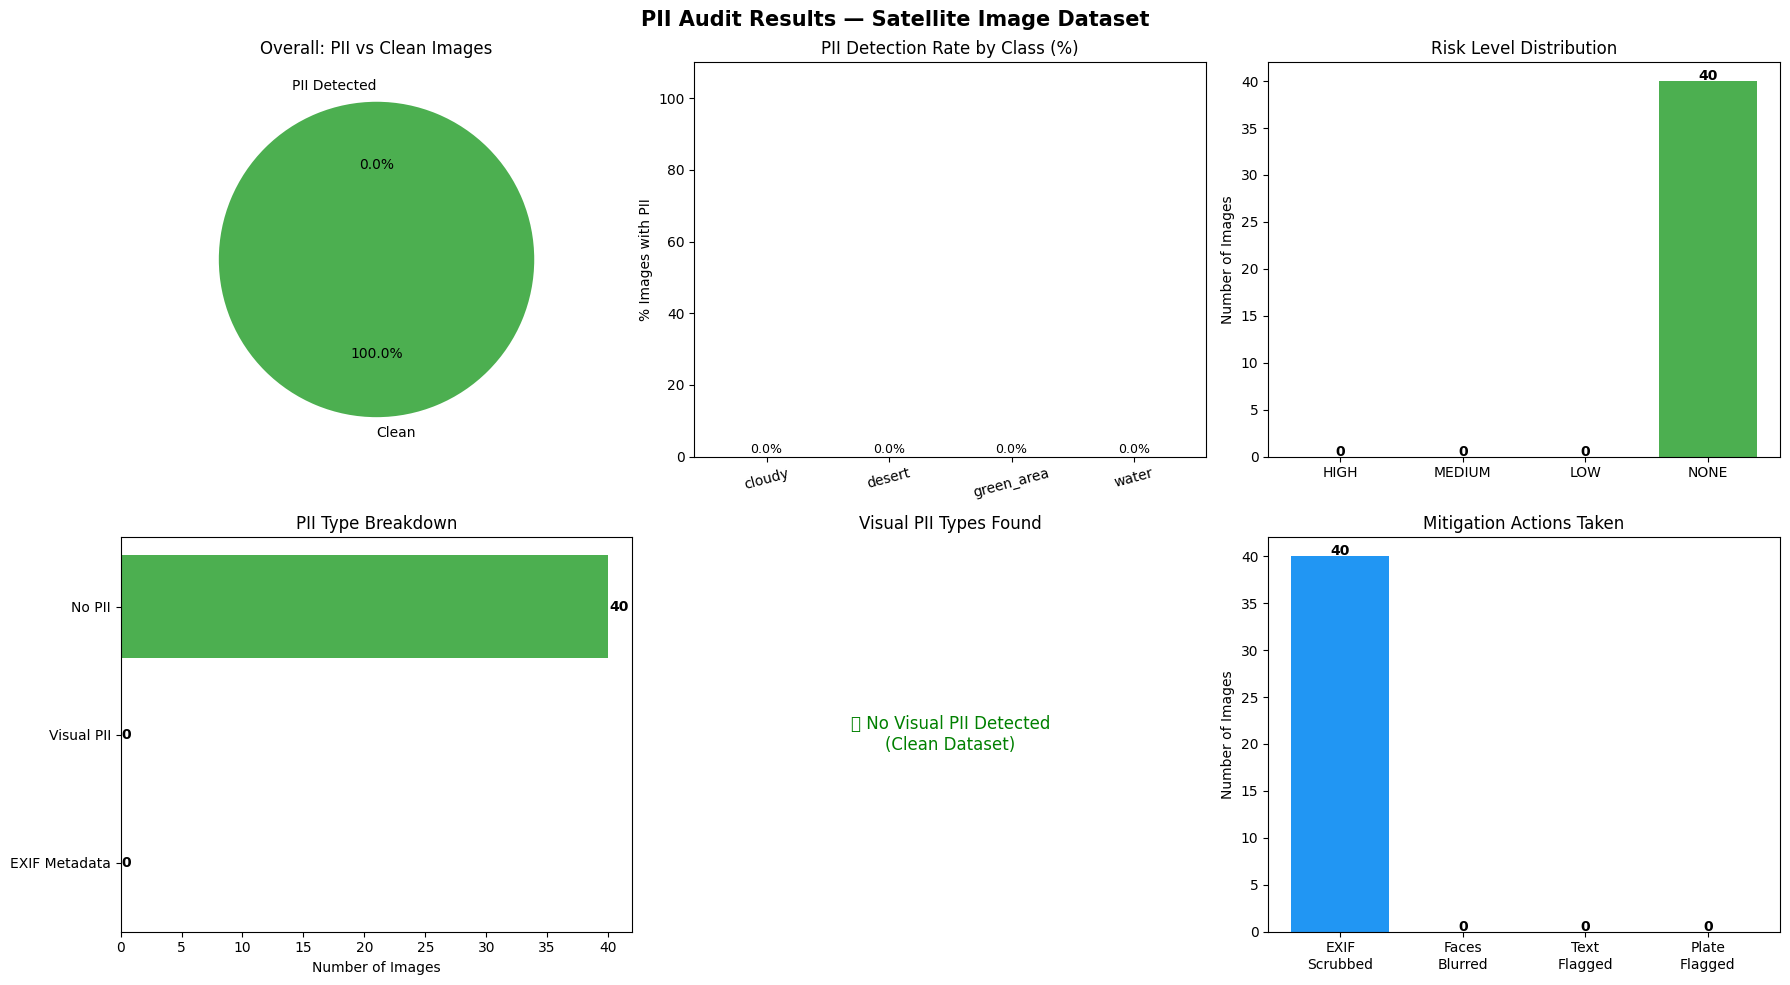

✅ Charts saved!


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("PII Audit Results — Satellite Image Dataset", fontsize=15, fontweight='bold')

# 1. Pie: PII vs Clean
ax = axes[0,0]
ax.pie([total - pii_count, pii_count],
       labels=['Clean', 'PII Detected'],
       autopct='%1.1f%%', colors=['#4CAF50','#F44336'], startangle=90)
ax.set_title('Overall: PII vs Clean Images')

# 2. Bar: PII rate per class
ax = axes[0,1]
class_rate = df.groupby('class')['pii_detected'].mean() * 100
bars = ax.bar(class_rate.index, class_rate.values,
              color=['#2196F3','#FF9800','#4CAF50','#9C27B0'])
ax.set_title('PII Detection Rate by Class (%)')
ax.set_ylabel('% Images with PII')
ax.set_ylim(0, 110)
for b, v in zip(bars, class_rate.values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=15)

# 3. Bar: Risk levels
ax = axes[0,2]
risk_counts = df['risk_level'].value_counts().reindex(['HIGH','MEDIUM','LOW','NONE'], fill_value=0)
colors = ['#F44336','#FF9800','#FFC107','#4CAF50']
ax.bar(risk_counts.index, risk_counts.values, color=colors)
ax.set_title('Risk Level Distribution')
ax.set_ylabel('Number of Images')
for i,(idx,v) in enumerate(risk_counts.items()):
    ax.text(i, v+0.1, str(v), ha='center', fontweight='bold')

# 4. Horizontal bar: PII type breakdown
ax = axes[1,0]
type_data = {'EXIF Metadata': exif_count,
             'Visual PII': visual_count,
             'No PII': total - pii_count}
ax.barh(list(type_data.keys()), list(type_data.values()),
        color=['#FF9800','#9C27B0','#4CAF50'])
ax.set_title('PII Type Breakdown')
ax.set_xlabel('Number of Images')
for i,(k,v) in enumerate(type_data.items()):
    ax.text(v+0.1, i, str(v), va='center', fontweight='bold')

# 5. Visual PII types
ax = axes[1,1]
all_vis = [t for row in audit_records for t in row['visual_types']]
if all_vis:
    vc = Counter(all_vis)
    ax.bar(list(vc.keys()), list(vc.values()), color=['#3F51B5','#009688','#FF5722'])
    ax.set_title('Visual PII Types Found')
    ax.set_ylabel('Count')
else:
    ax.text(0.5, 0.5, '✅ No Visual PII Detected\n(Clean Dataset)',
            ha='center', va='center', fontsize=12, color='green',
            transform=ax.transAxes)
    ax.set_title('Visual PII Types Found')
    ax.axis('off')

# 6. Mitigation actions
ax = axes[1,2]
mit = {
    'EXIF\nScrubbed': total,
    'Faces\nBlurred': sum(1 for r in audit_records if 'FACE' in r['visual_types']),
    'Text\nFlagged':  sum(1 for r in audit_records if 'TEXT_REGION' in r['visual_types']),
    'Plate\nFlagged': sum(1 for r in audit_records if 'PLATE_CANDIDATE' in r['visual_types'])
}
bars = ax.bar(list(mit.keys()), list(mit.values()),
              color=['#2196F3','#E91E63','#FF9800','#795548'])
ax.set_title('Mitigation Actions Taken')
ax.set_ylabel('Number of Images')
for b, v in zip(bars, mit.values()):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/reports/pii_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")


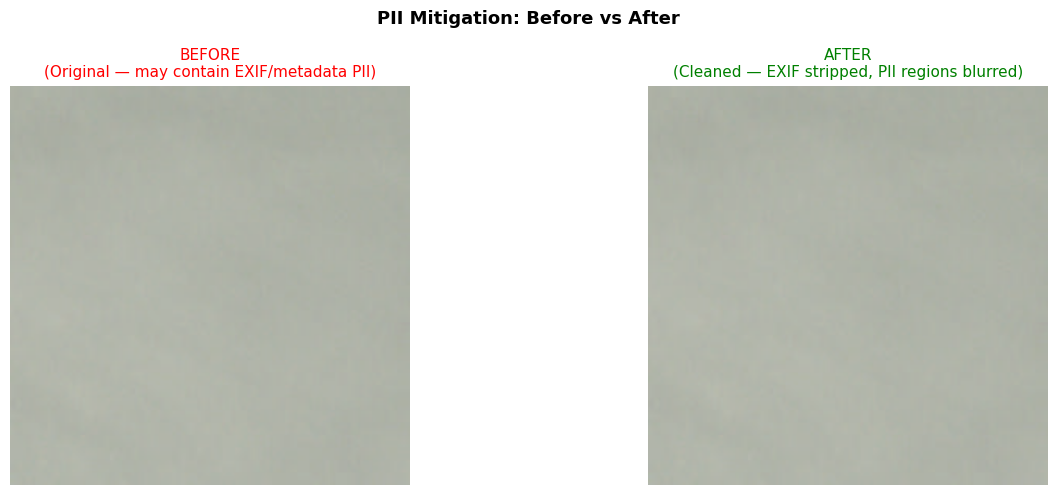

✅ Before/After comparison shown!


In [19]:
sample_cls  = CLASSES[0]
sample_imgs = list((Path(DATASET_PATH) / sample_cls).glob("*.jpg"))
if sample_imgs:
    orig_path  = str(sample_imgs[0])
    clean_path = f"{OUTPUT_PATH}/clean_images/{sample_cls}_{sample_imgs[0].name}"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("PII Mitigation: Before vs After", fontsize=13, fontweight='bold')

    orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(orig)
    axes[0].set_title("BEFORE\n(Original — may contain EXIF/metadata PII)", color='red', fontsize=11)
    axes[0].axis('off')

    if os.path.exists(clean_path):
        clean = cv2.cvtColor(cv2.imread(clean_path), cv2.COLOR_BGR2RGB)
        axes[1].imshow(clean)
        axes[1].set_title("AFTER\n(Cleaned — EXIF stripped, PII regions blurred)", color='green', fontsize=11)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print("✅ Before/After comparison shown!")


In [20]:
import shutil
from google.colab import files

# Zip the output folder
shutil.make_archive("pii_output", "zip", OUTPUT_PATH)
files.download("pii_output.zip")
print("✅ Downloaded pii_output.zip — contains clean images, CSV, JSON, and charts!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded pii_output.zip — contains clean images, CSV, JSON, and charts!
